# Notebook 07 — Evaluación Final en Test
**Predicción de Diagnóstico de Cáncer · UAX 2025/2026**

Sección cubierta: **Sección 7 — Evaluación Estándar**

Abrimos el test por primera vez. Todos los modelos se evalúan sobre
exactamente los mismos datos. Ningún resultado anterior se ha calculado
sobre este conjunto.

Contenido:
- 7.1 Carga de artefactos y probabilidades
- 7.2 Tabla de métricas completa (con Oracle de referencia)
- 7.3 Curvas ROC superpuestas
- 7.4 Curvas Precision-Recall superpuestas
- 7.5 Matrices de confusión
- 7.6 Gráfico de barras comparativo
- 7.7 Tabla de sensibilidad al umbral del mejor modelo
- 7.8 Análisis de falsos negativos — perfil de los errores críticos
- 7.9 Ranking final

**Carga:** probabilidades y artefactos de notebooks 05 y 06
**Genera:** `outputs/tables/test_results.csv` + figuras para slides

---
## Setup

In [ ]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib

from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score, recall_score,
    accuracy_score, brier_score_loss, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay,
)

warnings.filterwarnings('ignore')

ROOT      = os.path.abspath('..')
DATA_PROC = os.path.join(ROOT, 'data', 'processed')
OUT_FIGS  = os.path.join(ROOT, 'outputs', 'figures')
OUT_TABS  = os.path.join(ROOT, 'outputs', 'tables')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})
COLORS = {'LogReg (baseline)': '#888888', 'Random Forest': '#6ACC65',
          'XGBoost': '#D65F5F', 'LightGBM': '#B47CC7',
          'MLP': '#4878CF', 'Oracle': '#333333'}

---
## 7.1 Carga de artefactos y probabilidades

In [2]:
y_test  = np.load(os.path.join(DATA_PROC, 'y_test.npy'))

with open(os.path.join(DATA_PROC, 'meta.json')) as f:
    meta = json.load(f)
with open(os.path.join(DATA_PROC, 'mlp_meta.json')) as f:
    mlp_meta = json.load(f)

ORACLE_AUC    = meta['oracle_auc']
THRESHOLD_MLP = mlp_meta['threshold_optimal']

# Probabilidades clasicos + MLP
probas_classical = joblib.load(os.path.join(DATA_PROC, 'probas_classical.joblib'))
y_proba_mlp      = np.load(os.path.join(DATA_PROC, 'probas_mlp.npy'))

# X_test sin escalar (para analisis de FN y Oracle)
X_test_raw = pd.read_parquet(os.path.join(DATA_PROC, 'X_test_raw.parquet'))

# Recomputar Oracle Score sobre el test desde las features raw
def compute_oracle(df):
    logit = (
        -4.0
        + 2.0 * df['mut_BRCA1']
        + 1.8 * df['mut_TP53']
        + 1.5 * df['fumador']
        + 1.4 * df['mut_KRAS']
        + 1.2 * (df['glucosa'] > 130).astype(int)
        + 1.1 * df['obesidad']
        + 1.0 * df['mut_EGFR']
        + 0.9 * (df['hemoglobina'] < 11).astype(int)
        + 0.8 * df['mut_PIK3CA']
        + 0.7 * (df['leucocitos'] > 10).astype(int)
        + 0.6 * df['mut_BRAF']
        + 0.5 * df['hipertension']
        + 0.4 * (df['edad'] > 55).astype(int)
    )
    if 'actividad_fisica_ord' in df.columns:
        logit += -1.2 * (df['actividad_fisica_ord'] == 2).astype(int)
        logit += -0.6 * (df['actividad_fisica_ord'] == 1).astype(int)
    return 1 / (1 + np.exp(-logit))

oracle_test = compute_oracle(X_test_raw).values

ALL_PROBAS = {**probas_classical, 'MLP': y_proba_mlp}
THRESHOLDS = {m: 0.50 for m in probas_classical}
THRESHOLDS['MLP'] = THRESHOLD_MLP

print(f"Test: {len(y_test):,} pacientes  |  prevalencia: {y_test.mean():.4f}")
print(f"Modelos cargados: {list(ALL_PROBAS.keys())}")
print(f"Umbral MLP optimo: {THRESHOLD_MLP:.2f}")
print(f"Oracle recomputado: AUC={roc_auc_score(y_test, oracle_test):.4f}")

Test: 10,001 pacientes  |  prevalencia: 0.1929
Modelos cargados: ['LogReg (baseline)', 'Random Forest', 'XGBoost', 'LightGBM', 'MLP']
Umbral MLP optimo: 0.70
Oracle recomputado: AUC=0.8362


---
## 7.2 Tabla de métricas completa

In [3]:
def evaluar(nombre, y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        'modelo':     nombre,
        'threshold':  threshold,
        'precision':  precision_score(y_true, y_pred, zero_division=0),
        'recall':     recall_score(y_true, y_pred, zero_division=0),
        'f1':         f1_score(y_true, y_pred, zero_division=0),
        'auc_roc':    roc_auc_score(y_true, y_proba),
        'pr_auc':     average_precision_score(y_true, y_proba),
        'brier':      brier_score_loss(y_true, y_proba),
        'accuracy':   accuracy_score(y_true, y_pred),
        'fn':         int(confusion_matrix(y_true, y_pred).ravel()[2]),
        'fp':         int(confusion_matrix(y_true, y_pred).ravel()[1]),
    }

records = []
for name, proba in ALL_PROBAS.items():
    records.append(evaluar(name, y_test, proba, THRESHOLDS[name]))

# Oracle como referencia de techo
if oracle_test is not None:
    records.append(evaluar('Oracle (techo)', y_test, oracle_test, 0.50))

df_res = pd.DataFrame(records).sort_values('f1', ascending=False).reset_index(drop=True)

# Columna % del Oracle
oracle_auc_test = roc_auc_score(y_test, oracle_test) if oracle_test is not None else ORACLE_AUC
df_res['pct_oracle'] = (df_res['auc_roc'] / oracle_auc_test * 100).round(1)

show_cols = ['modelo','threshold','precision','recall','f1','auc_roc','pr_auc','brier','fn','fp','pct_oracle']
print("=== RESULTADOS EN TEST ===")
print()
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 15)
display(df_res[show_cols])

df_res.to_csv(os.path.join(OUT_TABS, 'test_results.csv'), index=False)
print(f"\nTabla guardada en outputs/tables/test_results.csv")

=== RESULTADOS EN TEST ===



,modelo,threshold,precision,recall,f1,auc_roc,pr_auc,brier,fn,fp,pct_oracle
0,Random Forest,0.5000,0.4693,0.6848,0.5569,0.8273,0.5696,0.1480,608,1494,98.9000
1,MLP,0.7000,0.5514,0.5588,0.5551,0.8322,0.5884,0.1718,851,877,99.5000
2,XGBoost,0.5000,0.4348,0.7455,0.5493,0.8315,0.5847,0.1618,491,1869,99.4000
3,LightGBM,0.5000,0.4477,0.7097,0.5490,0.8291,0.5769,0.1547,560,1689,99.2000
4,LogReg (baseline),0.5000,0.4323,0.7470,0.5477,0.8347,0.5933,0.1647,488,1892,99.8000
5,Oracle (techo),0.5000,0.6797,0.3774,0.4853,0.8362,0.5907,0.1128,1201,343,100.0000



Tabla guardada en outputs/tables/test_results.csv


---
## 7.3 Curvas ROC superpuestas

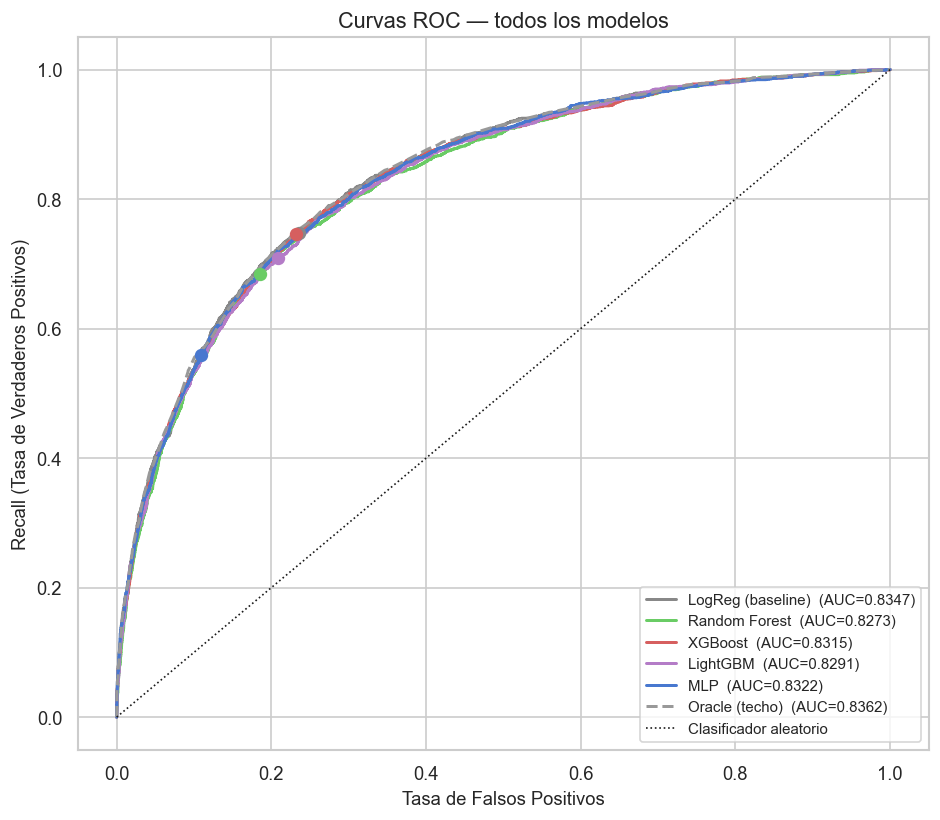

In [4]:
fig, ax = plt.subplots(figsize=(8, 7))
linestyles = {'Oracle (techo)': '--'}

for name, proba in {**ALL_PROBAS, **({'Oracle (techo)': oracle_test} if oracle_test is not None else {})}.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ls  = linestyles.get(name, '-')
    col = COLORS.get(name, '#999999')
    ax.plot(fpr, tpr, color=col, linestyle=ls, linewidth=1.8,
            label=f'{name}  (AUC={auc:.4f})')
    # Marcar punto de operacion al umbral elegido
    if name in THRESHOLDS:
        thr = THRESHOLDS[name]
        _, _, thrs = roc_curve(y_test, proba)
        idx = np.argmin(np.abs(thrs - thr))
        ax.plot(fpr[idx], tpr[idx], 'o', color=col, markersize=7, zorder=5)

ax.plot([0,1],[0,1],'k:',linewidth=1, label='Clasificador aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Recall (Tasa de Verdaderos Positivos)')
ax.set_title('Curvas ROC — todos los modelos')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIGS, '18_roc_curves.png'), bbox_inches='tight')
plt.show()

---
## 7.4 Curvas Precision-Recall superpuestas

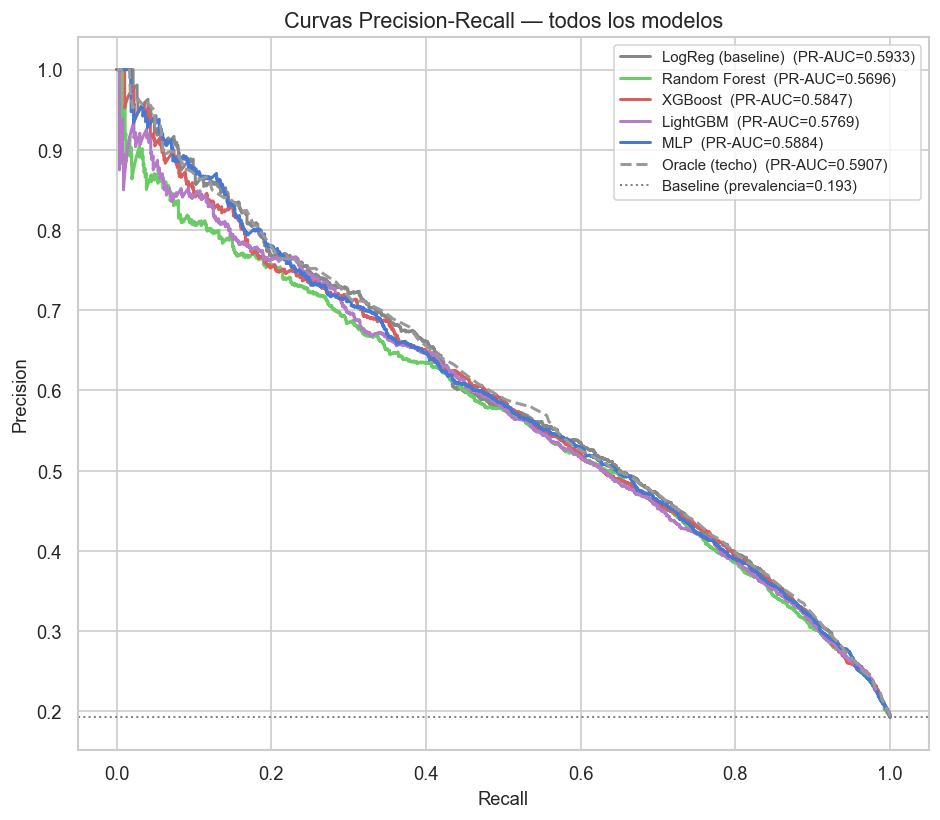

In [5]:
fig, ax = plt.subplots(figsize=(8, 7))
prev = y_test.mean()

for name, proba in {**ALL_PROBAS, **({'Oracle (techo)': oracle_test} if oracle_test is not None else {})}.items():
    prec, rec, _ = precision_recall_curve(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    ls  = linestyles.get(name, '-')
    col = COLORS.get(name, '#999999')
    ax.plot(rec, prec, color=col, linestyle=ls, linewidth=1.8,
            label=f'{name}  (PR-AUC={pr_auc:.4f})')

ax.axhline(prev, color='gray', linestyle=':', linewidth=1.2,
           label=f'Baseline (prevalencia={prev:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Curvas Precision-Recall — todos los modelos')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIGS, '19_pr_curves.png'), bbox_inches='tight')
plt.show()

---
## 7.5 Matrices de confusión

Mejor modelo clasico por F1: Random Forest


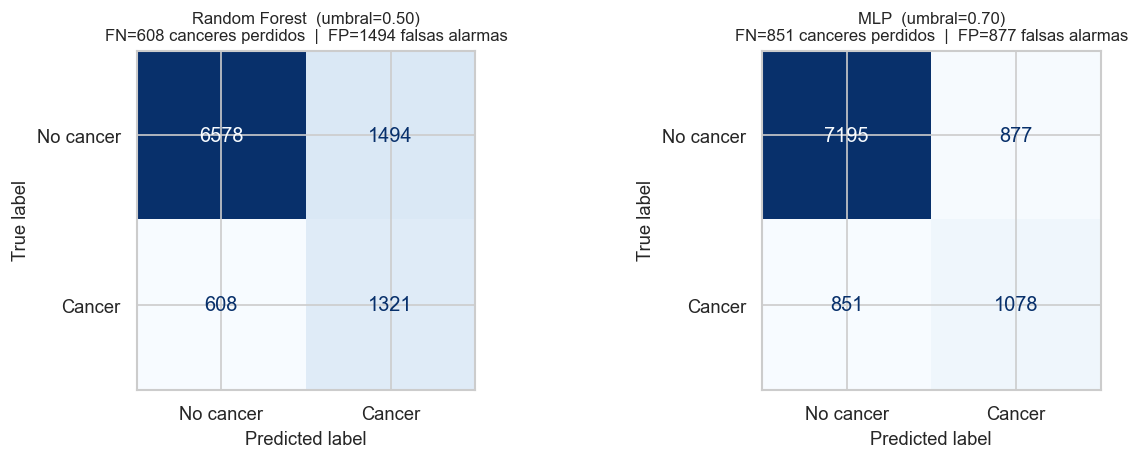

In [6]:
# Mejor modelo clásico y MLP
best_classic = df_res[~df_res['modelo'].isin(['MLP','Oracle (techo)'])].iloc[0]['modelo']
print(f"Mejor modelo clasico por F1: {best_classic}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, name in zip(axes, [best_classic, 'MLP']):
    proba = ALL_PROBAS[name]
    thr   = THRESHOLDS[name]
    y_pred = (proba >= thr).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    disp = ConfusionMatrixDisplay(cm, display_labels=['No cancer', 'Cancer'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}  (umbral={thr:.2f})\n'
                 f'FN={fn} canceres perdidos  |  FP={fp} falsas alarmas',
                 fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUT_FIGS, '20_confusion_matrices.png'), bbox_inches='tight')
plt.show()

---
## 7.6 Gráfico de barras comparativo

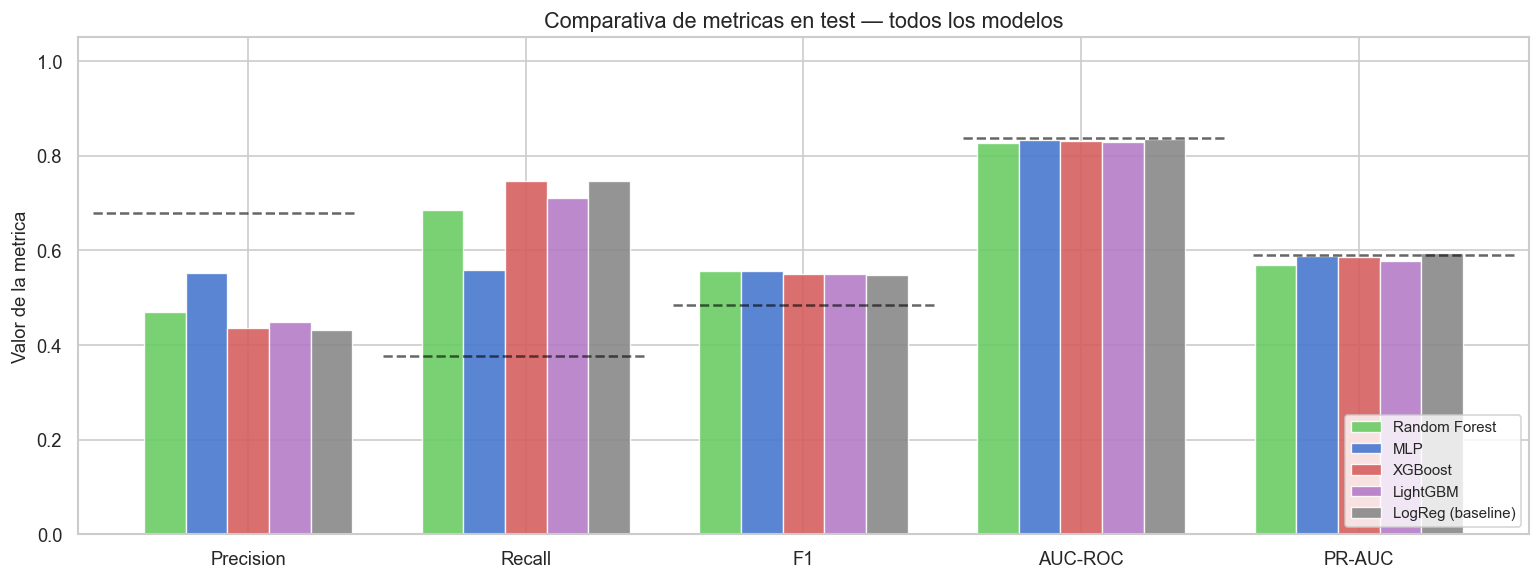

In [7]:
metrics_plot = ['precision','recall','f1','auc_roc','pr_auc']
df_plot = df_res[~df_res['modelo'].isin(['Oracle (techo)'])].copy()

x   = np.arange(len(metrics_plot))
w   = 0.15
fig, ax = plt.subplots(figsize=(13, 5))

for i, (_, row) in enumerate(df_plot.iterrows()):
    name = row['modelo']
    vals = [row[m] for m in metrics_plot]
    col  = COLORS.get(name, '#999999')
    bars = ax.bar(x + i*w, vals, w, label=name, color=col,
                  edgecolor='white', linewidth=0.8, alpha=0.9)

# Oracle como lineas de referencia
if oracle_test is not None:
    oracle_row = df_res[df_res['modelo']=='Oracle (techo)'].iloc[0]
    for j, m in enumerate(metrics_plot):
        ax.axhline(oracle_row[m], xmin=(j)/len(metrics_plot)+0.01,
                   xmax=(j+1)/len(metrics_plot)-0.01,
                   color='black', linestyle='--', linewidth=1.5, alpha=0.6)

ax.set_xticks(x + w * (len(df_plot)-1)/2)
ax.set_xticklabels(['Precision','Recall','F1','AUC-ROC','PR-AUC'], fontsize=11)
ax.set_ylabel('Valor de la metrica')
ax.set_title('Comparativa de metricas en test — todos los modelos')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right', fontsize=9)

oracle_line = mpatches.Patch(color='black', linestyle='--', label='Oracle (techo)')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUT_FIGS, '21_metrics_comparison.png'), bbox_inches='tight')
plt.show()

---
## 7.7 Tabla de sensibilidad al umbral del mejor modelo

Tres escenarios operativos para el mejor modelo:
- **Agresivo**: prioriza Recall ≥ 0.90 (minimiza cánceres perdidos)
- **Óptimo F1**: balance Precision-Recall
- **Conservador**: umbral por defecto 0.50

In [8]:
best_model_name = df_res[~df_res['modelo'].isin(['Oracle (techo)'])].iloc[0]['modelo']
best_proba      = ALL_PROBAS[best_model_name]

# Umbral para Recall >= 0.90
thrs_sweep = np.arange(0.05, 0.95, 0.01)
recalls_sw = [recall_score(y_test, (best_proba>=t).astype(int), zero_division=0)
              for t in thrs_sweep]
f1s_sw     = [f1_score(y_test, (best_proba>=t).astype(int), zero_division=0)
              for t in thrs_sweep]

# Umbral agresivo: mayor umbral con recall >= 0.90
r90_candidates = [t for t, r in zip(thrs_sweep, recalls_sw) if r >= 0.90]
thr_aggressive = float(max(r90_candidates)) if r90_candidates else float(thrs_sweep[np.argmax(recalls_sw)])
thr_optimal    = float(thrs_sweep[np.argmax(f1s_sw)])
thr_default    = 0.50

scenarios = [
    ('Agresivo  (Recall>=0.90)', thr_aggressive),
    (f'Optimo F1 (umbral={thr_optimal:.2f})', thr_optimal),
    ('Conservador (umbral=0.50)', thr_default),
]

rows = []
for label, thr in scenarios:
    y_pred = (best_proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    n_pos = int(y_test.sum())
    rows.append({
        'escenario':  label,
        'umbral':     thr,
        'recall':     recall_score(y_test, y_pred),
        'precision':  precision_score(y_test, y_pred, zero_division=0),
        'f1':         f1_score(y_test, y_pred, zero_division=0),
        'fn':         fn,
        'fp':         fp,
        'canceres_detectados': tp,
        'de_un_total_de':      n_pos,
    })

df_thr = pd.DataFrame(rows)
print(f"=== Sensibilidad al umbral — {best_model_name} ===")
print()
display(df_thr)
print()
print("FN = canceres no detectados (el error mas costoso en cribado)")
print("FP = pacientes sanos con alarma innecesaria")

=== Sensibilidad al umbral — Random Forest ===



,escenario,umbral,recall,precision,f1,fn,fp,canceres_detectados,de_un_total_de
0,Agresivo (Recall>=0.90),0.2400,0.9082,0.3004,0.4515,177,4080,1752,1929
1,Optimo F1 (umbral=0.53),0.5300,0.6496,0.4945,0.5615,676,1281,1253,1929
2,Conservador (umbral=0.50),0.5000,0.6848,0.4693,0.5569,608,1494,1321,1929



FN = canceres no detectados (el error mas costoso en cribado)
FP = pacientes sanos con alarma innecesaria


---
## 7.8 Análisis de falsos negativos — perfil de los errores críticos

¿Quiénes son los pacientes con cáncer que el mejor modelo no detecta?
Comparamos el perfil medio del FN vs el TP para entender
las limitaciones clínicas reales del sistema.

In [9]:
best_proba  = ALL_PROBAS[best_model_name]
best_thr    = THRESHOLDS[best_model_name]
y_pred_best = (best_proba >= best_thr).astype(int)

# Indices en el test
pos_mask = y_test == 1
fn_mask  = (y_test == 1) & (y_pred_best == 0)   # cancer no detectado
tp_mask  = (y_test == 1) & (y_pred_best == 1)   # cancer detectado

# Reindexar X_test_raw con posiciones
X_pos = X_test_raw.reset_index(drop=True)

fn_data = X_pos[fn_mask]
tp_data = X_pos[tp_mask]

print(f"Pacientes con cancer en test: {pos_mask.sum()}")
print(f"  Detectados (TP): {tp_mask.sum()}  ({100*tp_mask.sum()/pos_mask.sum():.1f}%)")
print(f"  Perdidos   (FN): {fn_mask.sum()}  ({100*fn_mask.sum()/pos_mask.sum():.1f}%)")
print()

# Features clave para comparar
key_feats = ['n_mutaciones','weighted_mut_burden','fumador','obesidad',
             'glucosa_alta','hemoglobina_baja','edad','glucosa','hemoglobina']
key_feats = [f for f in key_feats if f in X_pos.columns]

comparison = pd.DataFrame({
    'TP (detectados)': tp_data[key_feats].mean(),
    'FN (perdidos)':   fn_data[key_feats].mean(),
}).round(3)
comparison['diferencia'] = (comparison['FN (perdidos)'] - comparison['TP (detectados)']).round(3)

print("=== Perfil medio: TP vs FN ===")
print()
display(comparison)

Pacientes con cancer en test: 1929
  Detectados (TP): 1321  (68.5%)
  Perdidos   (FN): 608  (31.5%)

=== Perfil medio: TP vs FN ===



,TP (detectados),FN (perdidos),diferencia
n_mutaciones,1.3660,0.4520,-0.9140
weighted_mut_burden,1.9590,0.5540,-1.4050
fumador,0.6650,0.4130,-0.2520
obesidad,0.6260,0.3780,-0.2480
glucosa_alta,0.2320,0.0580,-0.1740
hemoglobina_baja,0.0650,0.0310,-0.0340
edad,56.8930,54.6320,-2.2610
glucosa,111.3740,101.0620,-10.3120
hemoglobina,13.5850,14.0520,0.4670


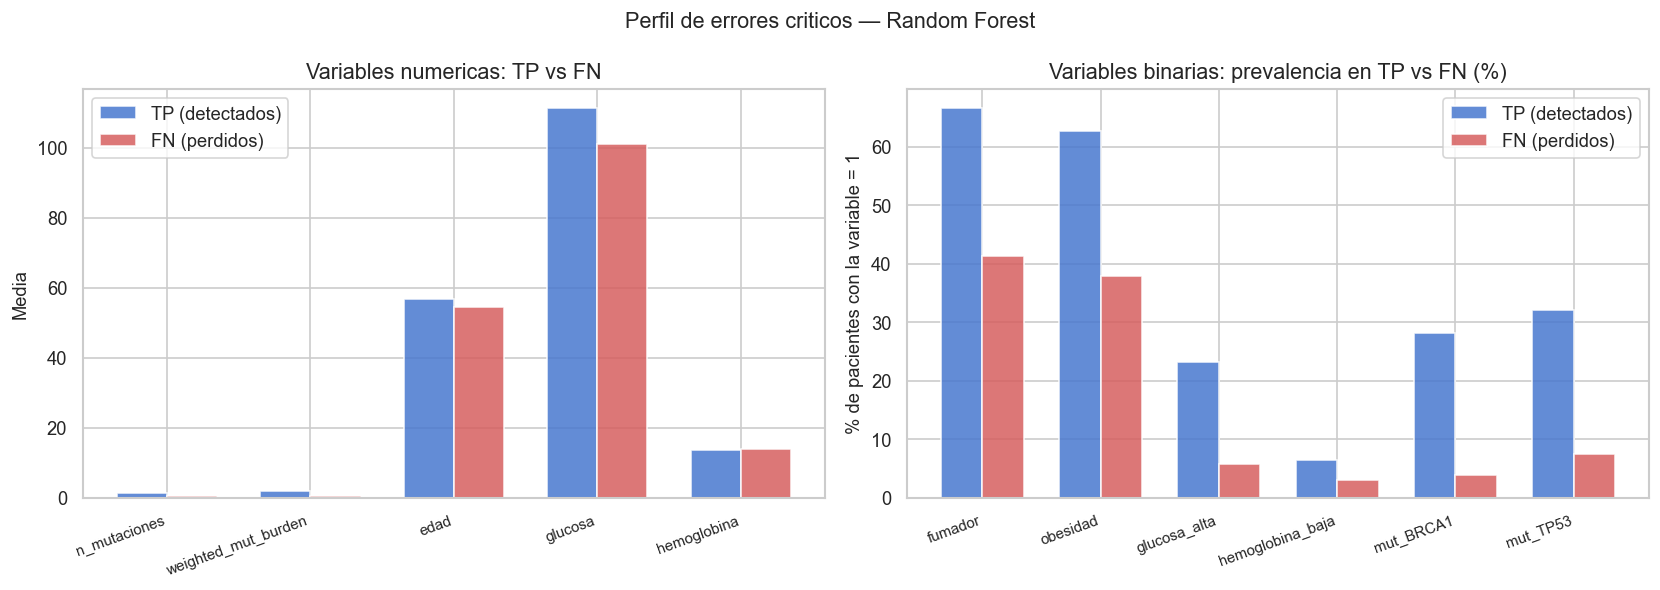


Interpretacion:
Los FN tienen menos mutaciones y menores marcadores de riesgo que los TP.
Son los casos 'silenciosos': cancer sin el patron genetico tipico.
Esta es la limitacion fundamental del dataset sintetico actual.


In [10]:
# Visualizacion del perfil FN vs TP
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: variables numericas
num_feats = ['n_mutaciones','weighted_mut_burden','edad','glucosa','hemoglobina']
num_feats = [f for f in num_feats if f in X_pos.columns]

x = np.arange(len(num_feats))
w = 0.35
axes[0].bar(x - w/2, [tp_data[f].mean() for f in num_feats], w,
            label='TP (detectados)', color='#4878CF', alpha=0.85)
axes[0].bar(x + w/2, [fn_data[f].mean() for f in num_feats], w,
            label='FN (perdidos)',   color='#D65F5F', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(num_feats, rotation=20, ha='right', fontsize=9)
axes[0].set_title('Variables numericas: TP vs FN')
axes[0].set_ylabel('Media')
axes[0].legend()

# Panel 2: variables binarias
bin_feats = ['fumador','obesidad','glucosa_alta','hemoglobina_baja','mut_BRCA1','mut_TP53']
bin_feats = [f for f in bin_feats if f in X_pos.columns]

x2 = np.arange(len(bin_feats))
axes[1].bar(x2 - w/2, [tp_data[f].mean()*100 for f in bin_feats], w,
            label='TP (detectados)', color='#4878CF', alpha=0.85)
axes[1].bar(x2 + w/2, [fn_data[f].mean()*100 for f in bin_feats], w,
            label='FN (perdidos)',   color='#D65F5F', alpha=0.85)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(bin_feats, rotation=20, ha='right', fontsize=9)
axes[1].set_title('Variables binarias: prevalencia en TP vs FN (%)')
axes[1].set_ylabel('% de pacientes con la variable = 1')
axes[1].legend()

plt.suptitle(f'Perfil de errores criticos — {best_model_name}', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIGS, '22_false_negative_profile.png'), bbox_inches='tight')
plt.show()

print()
print("Interpretacion:")
print("Los FN tienen menos mutaciones y menores marcadores de riesgo que los TP.")
print("Son los casos 'silenciosos': cancer sin el patron genetico tipico.")
print("Esta es la limitacion fundamental del dataset sintetico actual.")

---
## 7.9 Ranking final

In [11]:
df_rank = df_res[~df_res['modelo'].isin(['Oracle (techo)'])].copy()
df_rank = df_rank.sort_values('recall', ascending=False).reset_index(drop=True)
df_rank.index += 1

print("=== RANKING FINAL — ordenado por Recall (criterio primario en cribado) ===")
print()
rank_cols = ['modelo','threshold','recall','precision','f1','auc_roc','pr_auc','fn','pct_oracle']
display(df_rank[rank_cols])

print()
winner = df_rank.iloc[0]
print(f"Modelo recomendado: {winner['modelo']}")
print(f"  Umbral operativo: {winner['threshold']:.2f}")
print(f"  Recall:   {winner['recall']:.4f}  ({100*winner['recall']:.1f}% de canceres detectados)")
print(f"  F1:       {winner['f1']:.4f}")
print(f"  AUC-ROC:  {winner['auc_roc']:.4f}  ({winner['pct_oracle']:.1f}% del Oracle)")
print(f"  FN test:  {int(winner['fn'])} canceres no detectados de {int(y_test.sum())}")
print()
print("Listo para Notebook 08 — Capa Clinica")

=== RANKING FINAL — ordenado por Recall (criterio primario en cribado) ===



,modelo,threshold,recall,precision,f1,auc_roc,pr_auc,fn,pct_oracle
1,LogReg (baseline),0.5000,0.7470,0.4323,0.5477,0.8347,0.5933,488,99.8000
2,XGBoost,0.5000,0.7455,0.4348,0.5493,0.8315,0.5847,491,99.4000
3,LightGBM,0.5000,0.7097,0.4477,0.5490,0.8291,0.5769,560,99.2000
4,Random Forest,0.5000,0.6848,0.4693,0.5569,0.8273,0.5696,608,98.9000
5,MLP,0.7000,0.5588,0.5514,0.5551,0.8322,0.5884,851,99.5000



Modelo recomendado: LogReg (baseline)
  Umbral operativo: 0.50
  Recall:   0.7470  (74.7% de canceres detectados)
  F1:       0.5477
  AUC-ROC:  0.8347  (99.8% del Oracle)
  FN test:  488 canceres no detectados de 1929

Listo para Notebook 08 — Capa Clinica
